# Chapter 7 Companion Notebook
## Interpretable Risk Segmentation with Classification Trees

This notebook is the Python companion for **Chapter 7** of *Risk Analytics*.

It has two purposes:

1. **Replication mode**: reproduce Table 7.1, Table 7.2, and Figures 7.1--7.8 used in the chapter.
2. **Exploration mode**: let readers change the train/validation/test split, tree depths, splitting criteria, operating thresholds, displayed tree depth, and selected curves.

The chapter uses classification trees as interpretable risk-identification systems. The notebook therefore emphasizes model construction, threshold choice, out-of-sample evaluation, ROC/AUC, precision--recall analysis, log-loss, Cohen's Kappa, and confusion-matrix interpretation.

## 0. Imports, folders, and global user settings

This cell defines all main settings in one place. Readers can change these values and then run the notebook again.

**Important folder logic.** The package already contains the book figures in `figures/chapter_7/`. Running the notebook regenerates those figures and overwrites the existing files. This is intentional: the figures are included for convenience, but the notebook is designed to reproduce them.

**Dataset logic.** The dataset file is included in the package under `data/default of credit card clients.xls`. Readers can run the notebook on another if they keep the same folder structure, or if they change `DATA_PATH` below to point to their own copy of the data.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    cohen_kappa_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

# ------------------------------------------------------------
# Reproducibility and paths
# ------------------------------------------------------------
RANDOM_STATE = 42
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures" / "chapter_7"
TAB_DIR = ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "default of credit card clients.xls"

# ------------------------------------------------------------
# Train/validation/test split parameters
# ------------------------------------------------------------
# TEST_SIZE is the final holdout share used only for final reporting.
# VALIDATION_SIZE_WITHIN_TRAIN is the share of the remaining data used for threshold selection.
# With the default values: 60% training, 20% validation, 20% test.
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.25

# ------------------------------------------------------------
# Tree grid parameters
# ------------------------------------------------------------
DEPTHS = [2, 3, 4, 5, 6, 7, 8, 10]
CRITERIA = ["gini", "entropy", "log_loss"]
CRITERION_LABEL = {"gini": "Gini", "entropy": "Entropy", "log_loss": "Log-loss"}
MIN_SAMPLES_LEAF = 50

# ------------------------------------------------------------
# Threshold-selection parameters
# ------------------------------------------------------------
THRESHOLD_METHOD = "f1"  # options: "f1", "youden", "fixed", "top_share"
FIXED_THRESHOLD = 0.50
TOP_SHARE = 0.10

# ------------------------------------------------------------
# Figure customization parameters
# ------------------------------------------------------------
TREE_CRITERION_TO_DISPLAY = "gini" 
TREE_DEPTH_TO_DISPLAY = 3

# Curves shown in Figures 7.5 and 7.6.
# Use tuples of (criterion, depth). Readers can change this list.
SELECTED_CURVES = [("gini", 3), ("gini", 8), ("entropy", 7), ("log_loss", 6)]

# Models shown in Figure 7.8. Readers can change this list.
SELECTED_CONFUSION_MATRICES = [("gini", 3), ("gini", 8), ("entropy", 7), ("log_loss", 6)]

print("Working folder:", ROOT)
print("Data path:", DATA_PATH)
print("Figure folder:", FIG_DIR)
print("Table folder:", TAB_DIR)

Working folder: /Users/fernando/Documents/BOOK_PROJECTS/Risk Analytics/Chapter 7/Ch_7_python
Data path: /Users/fernando/Documents/BOOK_PROJECTS/Risk Analytics/Chapter 7/Ch_7_python/data/default of credit card clients.xls
Figure folder: /Users/fernando/Documents/BOOK_PROJECTS/Risk Analytics/Chapter 7/Ch_7_python/figures/chapter_7
Table folder: /Users/fernando/Documents/BOOK_PROJECTS/Risk Analytics/Chapter 7/Ch_7_python/tables


## 1. Load and prepare the Taiwan credit-card default dataset

This cell reads the original Excel file, standardizes common column-name variants, creates two six-month summary variables used in the descriptive table, and identifies the target variable.

The original UCI Excel file has a metadata row before the actual header, so the file is read with `header=1`.

In [2]:
def load_credit_default(path: Path) -> pd.DataFrame:
    """Load and clean the Taiwan credit-card default dataset."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Cannot find {path}. Check DATA_PATH or place the Excel file in the data folder."
        )

    df = pd.read_excel(path, header=1) if path.suffix.lower() in [".xls", ".xlsx"] else pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    rename = {
        "default payment next month": "default.payment.next.month",
        "default.payment.next.month": "default.payment.next.month",
        "Y": "default.payment.next.month",
        "X1": "LIMIT_BAL", "X2": "SEX", "X3": "EDUCATION", "X4": "MARRIAGE", "X5": "AGE",
        "X6": "PAY_0", "X7": "PAY_2", "X8": "PAY_3", "X9": "PAY_4", "X10": "PAY_5", "X11": "PAY_6",
        "X12": "BILL_AMT1", "X13": "BILL_AMT2", "X14": "BILL_AMT3", "X15": "BILL_AMT4", "X16": "BILL_AMT5", "X17": "BILL_AMT6",
        "X18": "PAY_AMT1", "X19": "PAY_AMT2", "X20": "PAY_AMT3", "X21": "PAY_AMT4", "X22": "PAY_AMT5", "X23": "PAY_AMT6",
    }
    df = df.rename(columns=rename)

    # Remove accidental index columns.
    for c in list(df.columns):
        if str(c).lower().startswith("unnamed") or c == "ID":
            df = df.drop(columns=[c])

    required = [
        "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
        "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
        "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
        "default.payment.next.month",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df = df[required].copy()
    df["BILL"] = df[[f"BILL_AMT{i}" for i in range(1, 7)]].mean(axis=1)
    df["PAY"] = df[[f"PAY_AMT{i}" for i in range(1, 7)]].mean(axis=1)
    df["PAY_STATUS_MEAN"] = df[["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]].mean(axis=1)
    return df


df = load_credit_default(DATA_PATH)
target = "default.payment.next.month"
print(df.shape)
df.head()

(30000, 27)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL,PAY,PAY_STATUS_MEAN
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,1284.000000,114.833333,-0.333333
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,2846.166667,833.333333,0.500000
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,16942.166667,1836.333333,0.000000
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,38555.666667,1398.000000,0.000000
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,18223.166667,9841.500000,-0.333333


## 2. Table 7.1 and Figures 7.1--7.3

These cells reproduce the descriptive evidence in the chapter:

- **Table 7.1**: selected descriptive statistics.
- **Figure 7.1**: class distribution.
- **Figure 7.2**: observed default rate by most recent repayment status.
- **Figure 7.3**: credit-limit distribution by default outcome.

The generated files are saved to the `tables/` and `figures/chapter_7/` folders.

In [3]:
# Table 7.1: selected descriptive statistics
variables = ["LIMIT_BAL", "AGE", "BILL", "PAY", "PAY_STATUS_MEAN"]
table_7_1 = df[variables].agg(["mean", "std", "min", "median", "max"]).T
table_7_1.columns = ["Mean", "Std. Dev.", "Min", "Median", "Max"]
table_7_1 = table_7_1.round(0).astype(int)

table_7_1.to_csv(TAB_DIR / "table_7_1_descriptive_statistics.csv")
table_7_1.to_latex(TAB_DIR / "table_7_1_descriptive_statistics.tex")
table_7_1

,Mean,Std. Dev.,Min,Median,Max
LIMIT_BAL,167484,129748,10000,140000,1000000
AGE,35,9,21,34,79
BILL,44977,63261,-56043,21052,877314
PAY,5275,10138,0,2397,627344
PAY_STATUS_MEAN,0,1,-2,0,6


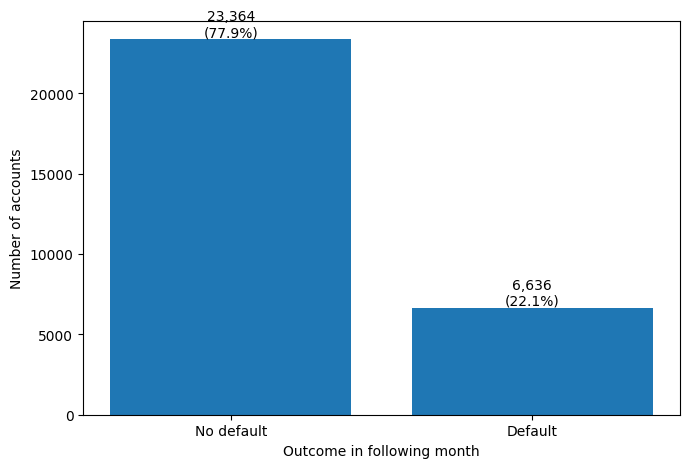

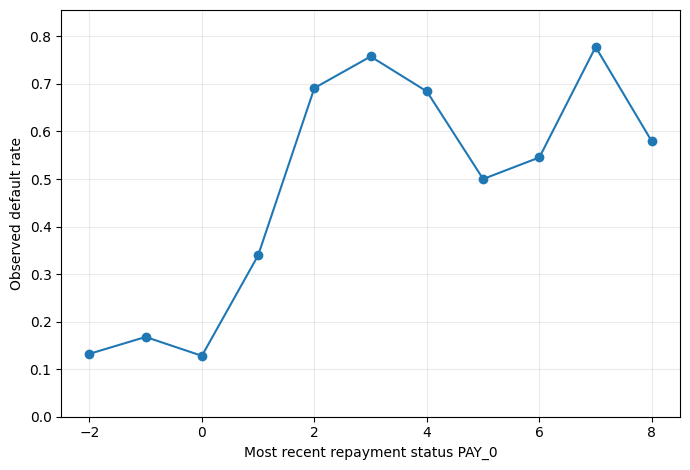

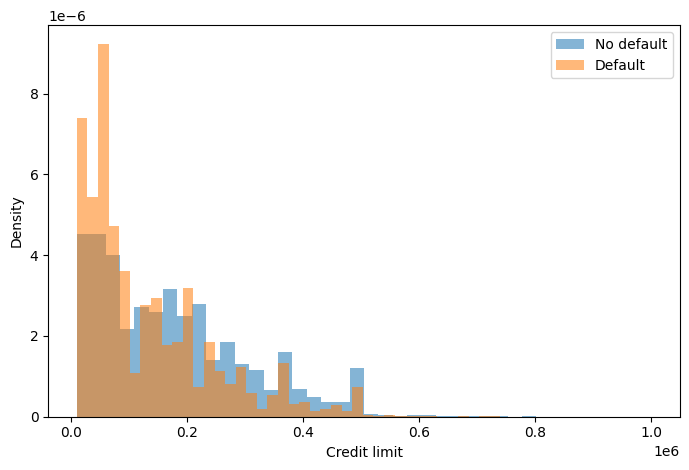

In [4]:
# Figure 7.1: class distribution
counts = df[target].value_counts().sort_index()
labels = ["No default", "Default"]
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(labels, counts.values)
ax.set_ylabel("Number of accounts")
ax.set_xlabel("Outcome in following month")
for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_7_1_class_distribution.png", dpi=300)
plt.show()

# Figure 7.2: default rate by PAY_0
pay0_rate = df.groupby("PAY_0")[target].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(pay0_rate["PAY_0"], pay0_rate[target], marker="o")
ax.set_xlabel("Most recent repayment status PAY_0")
ax.set_ylabel("Observed default rate")
ax.set_ylim(0, max(0.8, pay0_rate[target].max() * 1.10))
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_7_2_default_by_pay0.png", dpi=300)
plt.show()

# Figure 7.3: credit-limit distribution by outcome
fig, ax = plt.subplots(figsize=(7, 4.8))
for outcome, label in [(0, "No default"), (1, "Default")]:
    ax.hist(df.loc[df[target] == outcome, "LIMIT_BAL"], bins=40, alpha=0.55, density=True, label=label)
ax.set_xlabel("Credit limit")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_7_3_limit_by_outcome.png", dpi=300)
plt.show()

## 3. Training, validation, and test sets

This section separates three distinct tasks:

1. **Training set**: used to estimate the tree structure and terminal-node probabilities.
2. **Validation set**: used to choose the operating threshold for each fitted tree.
3. **Test set**: used only after the model and threshold have been fixed, to report out-of-sample performance.

This separation is essential. We do **not** fit on the test set. The test set is only used for final evaluation: Table 7.2 and Figures 7.5--7.8 use test-set outcomes and test-set predicted probabilities. Threshold-dependent results use thresholds chosen earlier on the validation set.

Readers can change the split parameters in Cell 0:

- `TEST_SIZE`
- `VALIDATION_SIZE_WITHIN_TRAIN`
- `RANDOM_STATE`

In [5]:
y = df[target].astype(int).values

# The modelling features exclude the constructed descriptive summaries BILL, PAY, and PAY_STATUS_MEAN.
# The original monthly bill, payment, and repayment variables remain in the model.
X = df.drop(columns=[target, "BILL", "PAY", "PAY_STATUS_MEAN"])

cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VALIDATION_SIZE_WITHIN_TRAIN,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Observations": [len(y_train), len(y_val), len(y_test)],
    "Default rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
split_summary

,Set,Observations,Default rate
0,Training,18000,0.221222
1,Validation,6000,0.221167
2,Test,6000,0.221167


## 4. Fit the tree grid and choose validation thresholds

This section fits all candidate trees defined in Cell 0:

- `CRITERIA`: splitting criteria, such as `gini`, `entropy`, and `log_loss`.
- `DEPTHS`: tree depths to estimate.
- `MIN_SAMPLES_LEAF`: minimum number of observations in each leaf.

The fitted tree uses the **training set only**. Then the threshold is selected using the **validation set only**.

The default threshold method is `f1`, which chooses the threshold that maximizes validation-set \(F_1\). This is more appropriate than automatically using 0.5 in an imbalanced default problem, because useful default-risk scores are often below 0.5.

Readers can change `THRESHOLD_METHOD` in Cell 0. Available options are:

- `f1`: maximize validation \(F_1\).
- `youden`: maximize sensitivity + specificity - 1.
- `fixed`: use `FIXED_THRESHOLD`.
- `top_share`: flag the top `TOP_SHARE` fraction of accounts by predicted risk.

In [6]:
def choose_threshold(y_true, scores, method="f1", fixed_threshold=0.5, top_share=0.10):
    """Choose an operating threshold using validation data."""
    scores = np.asarray(scores)
    if method == "fixed":
        tau = fixed_threshold
    elif method == "top_share":
        tau = float(np.quantile(scores, 1 - top_share))
    else:
        grid = np.unique(np.concatenate(([0.0, 0.01, 0.05], np.round(np.unique(scores), 6), [0.95, 0.99, 1.0])))
        best_value = -np.inf
        tau = 0.5
        for candidate in grid:
            y_hat = (scores >= candidate).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
            if method == "f1":
                value = f1_score(y_true, y_hat, zero_division=0)
            elif method == "youden":
                recall = tp / (tp + fn) if (tp + fn) else 0
                specificity = tn / (tn + fp) if (tn + fp) else 0
                value = recall + specificity - 1
            else:
                raise ValueError("Unknown threshold method. Use 'f1', 'youden', 'fixed', or 'top_share'.")
            if value > best_value:
                best_value = value
                tau = float(candidate)

    y_hat = (scores >= tau).astype(int)
    return {
        "threshold": tau,
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
    }


def make_tree(criterion, depth):
    return Pipeline([
        ("prep", preprocessor),
        ("tree", DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth,
            min_samples_leaf=MIN_SAMPLES_LEAF,
            random_state=RANDOM_STATE,
        )),
    ])

models = {}
thresholds = {}

for criterion in CRITERIA:
    for depth in DEPTHS:
        model = make_tree(criterion, depth)
        model.fit(X_train, y_train)  # fit on training data only
        val_scores = model.predict_proba(X_val)[:, 1]
        thresholds[(criterion, depth)] = choose_threshold(
            y_val, val_scores,
            method=THRESHOLD_METHOD,
            fixed_threshold=FIXED_THRESHOLD,
            top_share=TOP_SHARE,
        )
        models[(criterion, depth)] = model

threshold_table = pd.DataFrame([
    {
        "Criterion": CRITERION_LABEL[c],
        "Depth": d,
        "Threshold": v["threshold"],
        "Validation F1": v["f1"],
        "Validation precision": v["precision"],
        "Validation recall": v["recall"],
    }
    for (c, d), v in thresholds.items()
]).sort_values(["Criterion", "Depth"])

threshold_table

,Criterion,Depth,Threshold,Validation F1,Validation precision,Validation recall
8,Entropy,2,0.149272,0.492414,0.579592,0.428033
9,Entropy,3,0.367816,0.492414,0.579592,0.428033
10,Entropy,4,0.310580,0.517550,0.512953,0.522231
11,Entropy,5,0.367816,0.513615,0.578302,0.461944
12,Entropy,6,0.293251,0.517471,0.577530,0.468726
13,Entropy,7,0.301370,0.520988,0.573889,0.477016
14,Entropy,8,0.279070,0.524851,0.555556,0.497362
15,Entropy,10,0.277778,0.516502,0.470844,0.571967
0,Gini,2,0.149272,0.492414,0.579592,0.428033
1,Gini,3,0.367816,0.492414,0.579592,0.428033


## 5. Table 7.2: test-set performance

This section evaluates the fitted trees on the **test set**. The tree structure is already fixed from the training set, and the threshold is already fixed from the validation set.

Users can generate the full table, or filter it to selected criteria and depths by changing `TABLE_CRITERIA_TO_SHOW` and `TABLE_DEPTHS_TO_SHOW` below.

In [7]:
def evaluate_model_on_test(criterion, depth):
    """Evaluate one fitted model on the test set using its validation-selected threshold."""
    model = models[(criterion, depth)]
    scores = model.predict_proba(X_test)[:, 1]
    tau = thresholds[(criterion, depth)]["threshold"]
    y_hat = (scores >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    return {
        "Criterion": CRITERION_LABEL[criterion],
        "Depth": depth,
        "Threshold": tau,
        "Accuracy": accuracy_score(y_test, y_hat),
        "Precision": precision_score(y_test, y_hat, zero_division=0),
        "Recall": recall_score(y_test, y_hat, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "F1": f1_score(y_test, y_hat, zero_division=0),
        "AUC": roc_auc_score(y_test, scores),
        "Log-loss": log_loss(y_test, np.clip(scores, 1e-15, 1 - 1e-15)),
        "Kappa": cohen_kappa_score(y_test, y_hat),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

# User filter for partial tables.
# Set to None to show all fitted criteria/depths.
TABLE_CRITERIA_TO_SHOW = None       # e.g., ["gini", "log_loss"]
TABLE_DEPTHS_TO_SHOW = None         # e.g., [3, 6, 8]

rows = []
for criterion in CRITERIA:
    for depth in DEPTHS:
        if TABLE_CRITERIA_TO_SHOW is not None and criterion not in TABLE_CRITERIA_TO_SHOW:
            continue
        if TABLE_DEPTHS_TO_SHOW is not None and depth not in TABLE_DEPTHS_TO_SHOW:
            continue
        rows.append(evaluate_model_on_test(criterion, depth))

table_7_2 = pd.DataFrame(rows)
criterion_order = [CRITERION_LABEL[c] for c in CRITERIA]
table_7_2["Criterion"] = pd.Categorical(table_7_2["Criterion"], criterion_order, ordered=True)
table_7_2 = table_7_2.sort_values(["Criterion", "Depth"]).reset_index(drop=True)

# Export full table independently of the display filter.
full_table_7_2 = pd.DataFrame([evaluate_model_on_test(c, d) for c in CRITERIA for d in DEPTHS])
full_table_7_2["Criterion"] = pd.Categorical(full_table_7_2["Criterion"], criterion_order, ordered=True)
full_table_7_2 = full_table_7_2.sort_values(["Criterion", "Depth"]).reset_index(drop=True)
full_table_7_2.to_csv(TAB_DIR / "table_7_2_classification_performance.csv", index=False)
full_table_7_2.round(3).to_csv(TAB_DIR / "table_7_2_classification_performance_rounded.csv", index=False)
full_table_7_2.round(3).to_latex(TAB_DIR / "table_7_2_classification_performance.tex", index=False)

table_7_2.round(3)

,Criterion,Depth,Threshold,Accuracy,Precision,Recall,Specificity,F1,AUC,Log-loss,Kappa,TN,FP,FN,TP
0,Gini,2,0.149,0.804,0.575,0.429,0.910,0.491,0.674,0.463,0.373,4253,420,758,569
1,Gini,3,0.368,0.804,0.575,0.429,0.910,0.491,0.720,0.452,0.373,4253,420,758,569
2,Gini,4,0.311,0.783,0.509,0.507,0.861,0.508,0.731,0.449,0.368,4023,650,654,673
3,Gini,5,0.218,0.745,0.444,0.607,0.784,0.513,0.746,0.445,0.345,3662,1011,521,806
4,Gini,6,0.218,0.764,0.473,0.580,0.816,0.521,0.755,0.444,0.367,3815,858,557,770
5,Gini,7,0.297,0.796,0.544,0.492,0.883,0.517,0.754,0.446,0.388,4125,548,674,653
6,Gini,8,0.309,0.779,0.501,0.561,0.841,0.529,0.759,0.446,0.385,3931,742,583,744
7,Gini,10,0.298,0.771,0.485,0.579,0.825,0.528,0.756,0.503,0.378,3857,816,559,768
8,Entropy,2,0.149,0.804,0.575,0.429,0.910,0.491,0.674,0.463,0.373,4253,420,758,569
9,Entropy,3,0.368,0.804,0.575,0.429,0.910,0.491,0.720,0.452,0.373,4253,420,758,569


## 6. Figure 7.4: display an interpretable tree

This cell plots one selected tree. By default, it reproduces the chapter's depth-3 Gini tree.

Readers can change these parameters in Cell 0:

- `TREE_CRITERION_TO_DISPLAY`
- `TREE_DEPTH_TO_DISPLAY`

A deeper tree may be harder to read. For exploratory work, try depths 2--4 first.

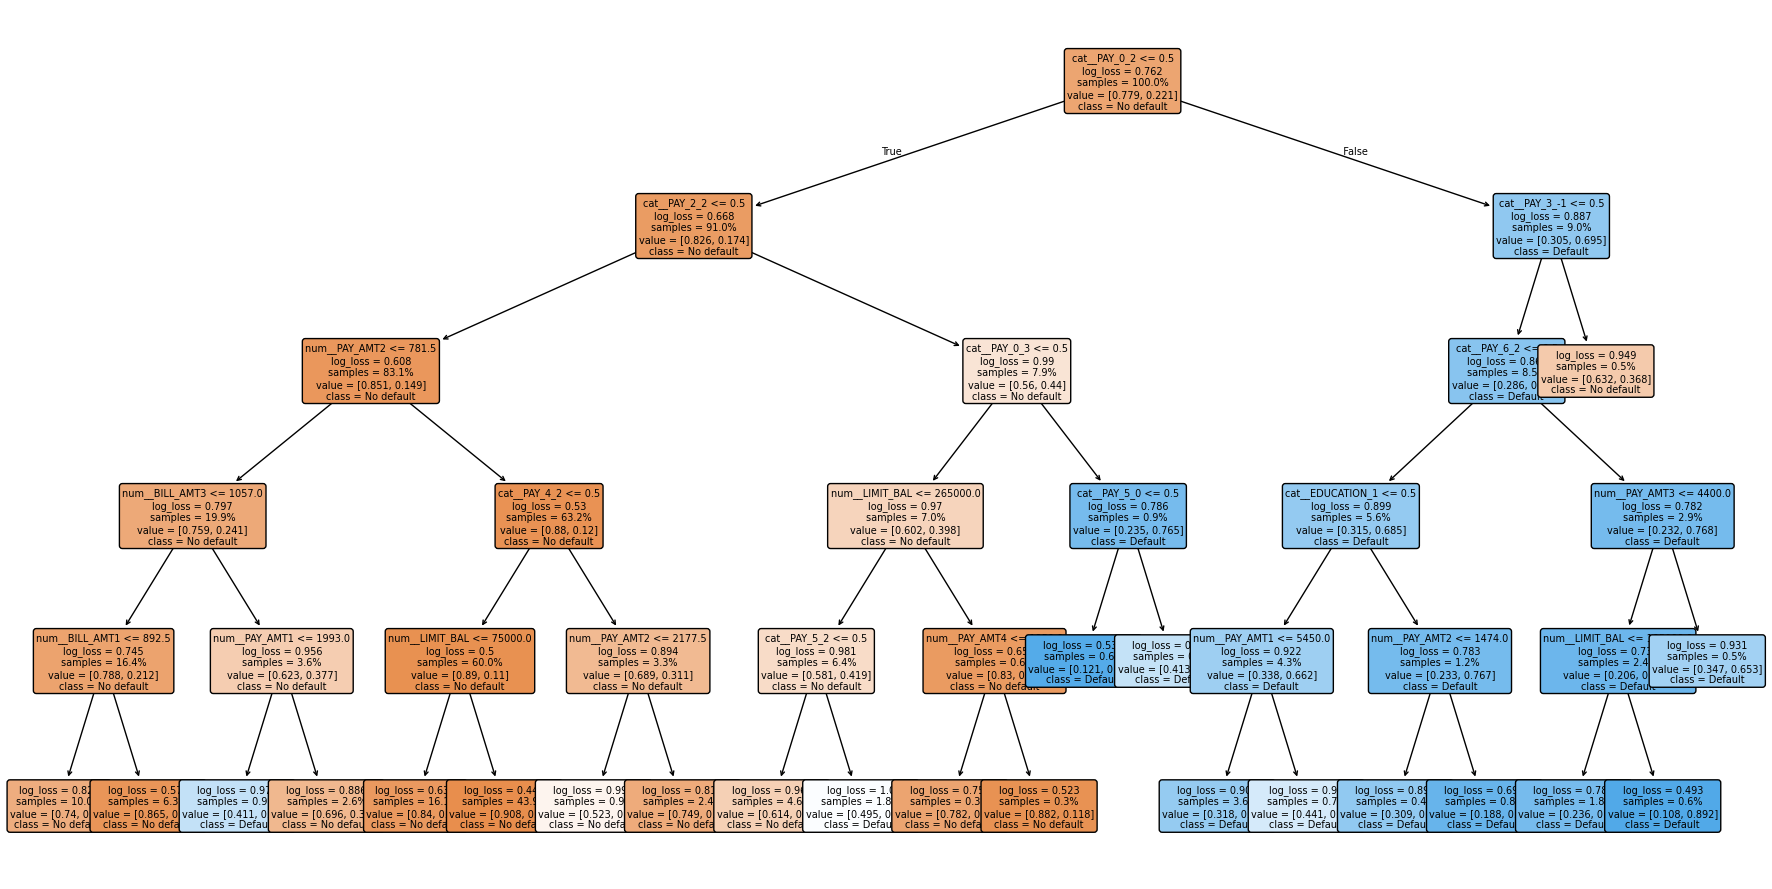

In [11]:
def plot_selected_tree(criterion, depth, filename="fig_7_4_shallow_tree_no_title.png"):
    """Plot one fitted decision tree."""
    if (criterion, depth) not in models:
        raise KeyError(f"Model {(criterion, depth)} not fitted. Check CRITERIA and DEPTHS in Cell 0.")
    model = models[(criterion, depth)]
    feature_names = model.named_steps["prep"].get_feature_names_out()
    fig, ax = plt.subplots(figsize=(18, 9))
    plot_tree(
        model.named_steps["tree"],
        feature_names=feature_names,
        class_names=["No default", "Default"],
        filled=True,
        impurity=True,
        proportion=True,
        rounded=True,
        fontsize=7,
        ax=ax,
    )
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_selected_tree(TREE_CRITERION_TO_DISPLAY, TREE_DEPTH_TO_DISPLAY)

## 7. Figures 7.5 and 7.6: ROC and precision--recall curves

Figures 7.5 and 7.6 are **threshold-free** test-set figures. They use the full test-set score distribution and sweep across possible thresholds.

The chapter plots a small representative subset of trees to keep the graphs readable. Readers can change `SELECTED_CURVES` in Cell 0 to show other trees, for example:

```python
SELECTED_CURVES = [("gini", 3), ("entropy", 8), ("log_loss", 10)]
```

In [ ]:
def model_label(criterion, depth):
    return f"{CRITERION_LABEL[criterion]} depth {depth}"


def validate_selection(selection):
    missing = [item for item in selection if item not in models]
    if missing:
        raise KeyError(f"These selected models are not fitted: {missing}")

validate_selection(SELECTED_CURVES)

# Figure 7.5: ROC curves
fig, ax = plt.subplots(figsize=(8, 5.2))
for criterion, depth in SELECTED_CURVES:
    scores = models[(criterion, depth)].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=f"{model_label(criterion, depth)} (AUC={roc_auc_score(y_test, scores):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random ranking")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / recall")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_7_5_roc_curves.png", dpi=300)
plt.show()

# Figure 7.6: precision--recall curves
fig, ax = plt.subplots(figsize=(8, 5.2))
base_rate = y_test.mean()
for criterion, depth in SELECTED_CURVES:
    scores = models[(criterion, depth)].predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(recall, precision, label=f"{model_label(criterion, depth)} (AP={ap:.3f})")
ax.axhline(base_rate, linestyle="--", linewidth=1, label=f"Base rate={base_rate:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_7_6_precision_recall_curves.png", dpi=300)
plt.show()

## 8. Figure 7.7: metric profiles for the fitted trees

This figure is no longer restricted to the book's specific curves. It summarizes the trees currently fitted from `CRITERIA` and `DEPTHS`.

If readers change the depth grid or criteria in Cell 0 and rerun the notebook, Figure 7.7 automatically updates. Entropy and log-loss can overlap because, in binary trees, both are closely related to information-gain/cross-entropy logic and may produce identical or very similar splits.

In [ ]:
def plot_metric_profiles(metrics_df, filename="fig_7_7_metric_profiles.png"):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    metric_list = ["AUC", "Log-loss", "F1", "Kappa"]
    ylabels = {
        "AUC": "AUC\n(higher is better)",
        "Log-loss": "Log-loss\n(lower is better)",
        "F1": "$F_1$\n(higher is better)",
        "Kappa": "Cohen's κ\n(higher is better)",
    }
    for ax, metric in zip(axes.ravel(), metric_list):
        for criterion_label in criterion_order:
            sub = metrics_df[metrics_df["Criterion"] == criterion_label]
            if not sub.empty:
                ax.plot(sub["Depth"], sub[metric], marker="o", label=criterion_label)
        ax.set_ylabel(ylabels[metric])
        ax.set_xlabel("Tree depth")
        ax.grid(True, alpha=0.25)
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300)
    plt.show()

plot_metric_profiles(full_table_7_2)

## 9. Figure 7.8: confusion matrices for selected trees

Figure 7.8 is threshold-dependent. It applies the validation-selected threshold for each selected tree to the test set.

Readers can change `SELECTED_CONFUSION_MATRICES` in Cell 0 to analyze their own selected trees.

In [ ]:
def plot_confusion_matrices(selection, filename="fig_7_8_confusion_matrices.png"):
    validate_selection(selection)
    n = len(selection)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (criterion, depth) in zip(axes, selection):
        scores = models[(criterion, depth)].predict_proba(X_test)[:, 1]
        tau = thresholds[(criterion, depth)]["threshold"]
        y_hat = (scores >= tau).astype(int)
        cm = confusion_matrix(y_test, y_hat)

        # Use a light sequential display so numbers remain readable.
        im = ax.imshow(cm, cmap="Blues", alpha=0.45)
        ax.set_title(f"{model_label(criterion, depth)}, threshold={tau:.2f}")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred. no default", "Pred. default"])
        ax.set_yticklabels(["True no default", "True default"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13, color="black")

    for ax in axes[len(selection):]:
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300)
    plt.show()

plot_confusion_matrices(SELECTED_CONFUSION_MATRICES)

## 10. Optional extension: compare threshold policies

This extension compares different operating policies for the selected curves:

- validation-selected threshold using the current `THRESHOLD_METHOD`;
- conventional 0.5 threshold;
- top-10% review policy.

This helps readers see that threshold choice is not a technical afterthought. It changes the number of alerts, missed defaults, and false alarms.

In [ ]:
def evaluate_at_threshold(y_true, scores, tau):
    y_hat = (scores >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    return {
        "Threshold": tau,
        "Accuracy": accuracy_score(y_true, y_hat),
        "Precision": precision_score(y_true, y_hat, zero_division=0),
        "Recall": recall_score(y_true, y_hat, zero_division=0),
        "F1": f1_score(y_true, y_hat, zero_division=0),
        "Kappa": cohen_kappa_score(y_true, y_hat),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Flagged accounts": int(y_hat.sum()),
    }

policy_rows = []
for criterion, depth in SELECTED_CURVES:
    scores = models[(criterion, depth)].predict_proba(X_test)[:, 1]
    policies = {
        "Validation-selected threshold": thresholds[(criterion, depth)]["threshold"],
        "Conventional 0.5 threshold": 0.5,
        "Top-10% review threshold": float(np.quantile(scores, 0.90)),
    }
    for policy_name, tau in policies.items():
        row = evaluate_at_threshold(y_test, scores, tau)
        row.update({"Model": model_label(criterion, depth), "Policy": policy_name})
        policy_rows.append(row)

policy_comparison = pd.DataFrame(policy_rows)
policy_comparison.to_csv(TAB_DIR / "threshold_policy_comparison.csv", index=False)
policy_comparison.round(3)

## 11. Build your own analysis

Use this section to fit and evaluate a custom tree without changing the main book-replication results.

Change the three parameters below and rerun the cell:

- `CUSTOM_CRITERION`
- `CUSTOM_DEPTH`
- `CUSTOM_THRESHOLD_METHOD`

In [ ]:
CUSTOM_CRITERION = "gini"      # "gini", "entropy", or "log_loss"
CUSTOM_DEPTH = 4
CUSTOM_THRESHOLD_METHOD = "f1" # "f1", "youden", "fixed", or "top_share"

custom_model = make_tree(CUSTOM_CRITERION, CUSTOM_DEPTH)
custom_model.fit(X_train, y_train)
custom_val_scores = custom_model.predict_proba(X_val)[:, 1]
custom_threshold_info = choose_threshold(
    y_val,
    custom_val_scores,
    method=CUSTOM_THRESHOLD_METHOD,
    fixed_threshold=FIXED_THRESHOLD,
    top_share=TOP_SHARE,
)

custom_scores = custom_model.predict_proba(X_test)[:, 1]
custom_result = evaluate_at_threshold(y_test, custom_scores, custom_threshold_info["threshold"])
custom_result.update({
    "Criterion": CRITERION_LABEL[CUSTOM_CRITERION],
    "Depth": CUSTOM_DEPTH,
    "Validation threshold method": CUSTOM_THRESHOLD_METHOD,
})

pd.DataFrame([custom_result]).round(3)

## 12. Export checklist

Running the notebook from top to bottom creates or updates:

```text
figures/chapter_7/fig_7_1_class_distribution.png
figures/chapter_7/fig_7_2_default_by_pay0.png
figures/chapter_7/fig_7_3_limit_by_outcome.png
figures/chapter_7/fig_7_4_shallow_tree_no_title.png
figures/chapter_7/fig_7_5_roc_curves.png
figures/chapter_7/fig_7_6_precision_recall_curves.png
figures/chapter_7/fig_7_7_metric_profiles.png
figures/chapter_7/fig_7_8_confusion_matrices.png

tables/table_7_1_descriptive_statistics.csv
tables/table_7_1_descriptive_statistics.tex
tables/table_7_2_classification_performance.csv
tables/table_7_2_classification_performance_rounded.csv
tables/table_7_2_classification_performance.tex
tables/threshold_policy_comparison.csv
```